**Problem 1. Palmer Penguin Species Data Set**

**This MEX2 was worked on in partnership with Ethan Capcuchino, in the same class.**

Download the Palmer Penguins Data set from:

https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data

The dataset contains 345 penguins from the Palmer Archipelago, Antarctica. Similar to the Iris Flowers Data set, it contains 4 numerical features of the penguins, namely: culmen length, culmen depth, flipper length, and body mass index.

Your task is to classify the penguins into their species (Adelie, Chinstrap, and Gentoo) based only on the culmen length and flipper length features.

a. [5 pts] First visualize the 4 numerical features of the data using Seaborn’s pair plot, then set the hue to the penguin species.

b. [25 pts] Split the samples into 75% Training and 25% Testing data at random with stratification (stratify=y). Build a pipeline with Standard scaler then SVC. Train the model using multi-class SVC in sklearn (You can try any arbitrary choice of kernel function, values of kernel parameters, multi-class strategy, and other hyper-parameters). Report the accuracy, macro-averaged F1-score, and confusion matrix of the trained model separately for the training data and testing data.

c. [20 pts] For your answer in letter (a), visualize the decision boundary in the space of culmen length vs. flipper length. Add a scatter plot of the training and test data set (use different markers for the two sets).


In [8]:
pip install kagglehub[pandas-datasets]

In [9]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "penguins_size.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "parulpandey/palmer-archipelago-antarctica-penguin-data",
  file_path,
)

print("First 5 records:\n", df.head())

/tmp/ipython-input-1103361971.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'palmer-archipelago-antarctica-penguin-data' dataset.
First 5 records:
   species     island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen              39.1             18.7              181.0   
1  Adelie  Torgersen              39.5             17.4              186.0   
2  Adelie  Torgersen              40.3             18.0              195.0   
3  Adelie  Torgersen               NaN              NaN                NaN   
4  Adelie  Torgersen              36.7             19.3              193.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3          NaN     NaN  
4       3450.0  FEMALE  


**a. [5 pts] First visualize the 4 numerical features of the data using Seaborn’s pair plot, then set the hue to the penguin species.**

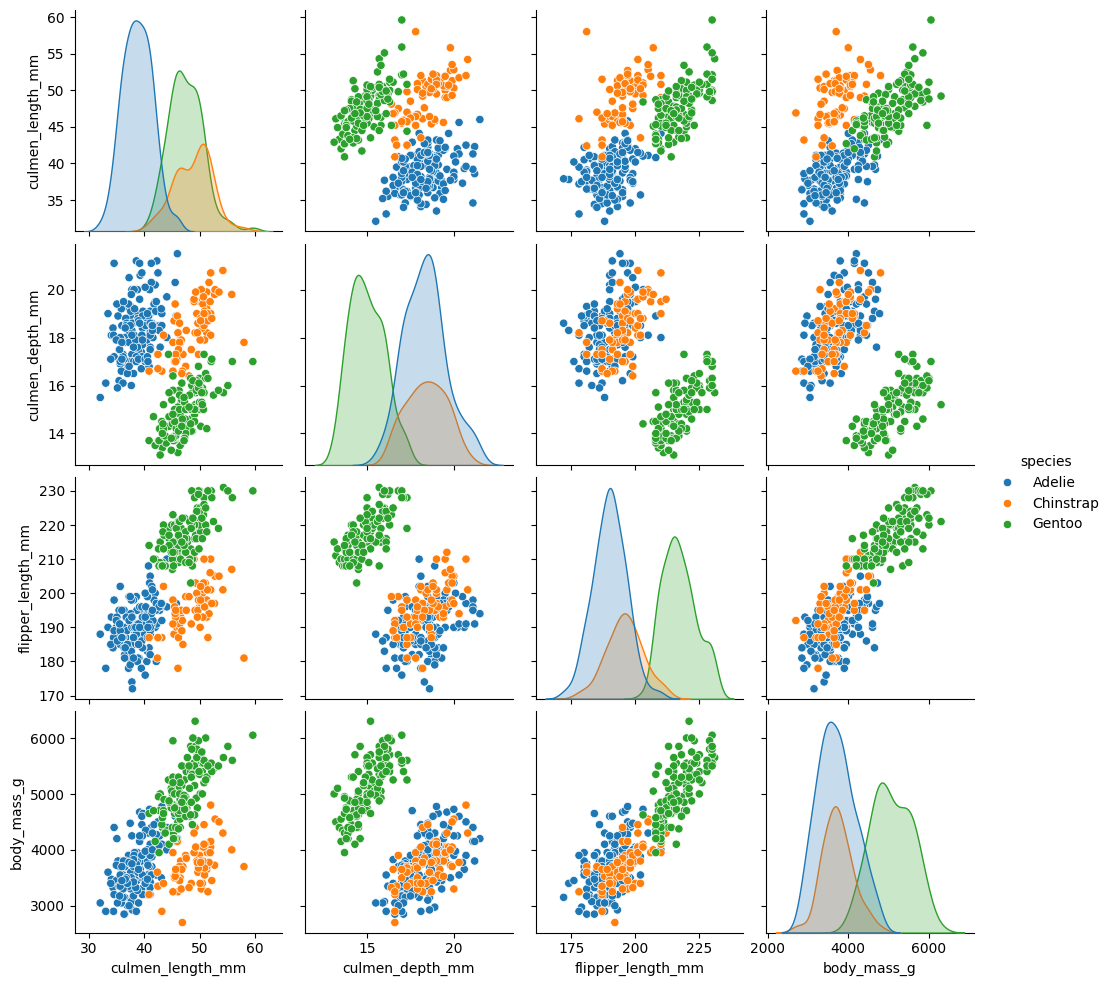

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue="species", vars=["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g"])
plt.show()


**[25 pts] Split the samples into 75% Training and 25% Testing data at random with stratification (stratify=y). Build a pipeline with Standard scaler then SVC. Train the model using multi-class SVC in sklearn (You can try any arbitrary choice of kernel function, values of kernel parameters, multi-class strategy, and other hyper-parameters). Report the accuracy, macro-averaged F1-score, and confusion matrix of the trained model separately for the training data and testing data.**

**Recall: Your task is to classify the penguins into their species (Adelie, Chinstrap, and Gentoo) based only on the culmen length and flipper length features.**

In [11]:
from sklearn.model_selection import train_test_split

# Encountered: Input X contains NaN; To avoid this
df = df.dropna()

X = df[["culmen_length_mm", "flipper_length_mm"]].to_numpy()
y = df["species"]

# 75% training and 25% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)

In [12]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multiclass import OneVsOneClassifier
from sklearn.multiclass import OutputCodeClassifier

# Build a pipeline with Standard scaler then SVC
svm_ovo = OneVsOneClassifier(make_pipeline(StandardScaler(), SVC())).fit(X_train,y_train)

Training


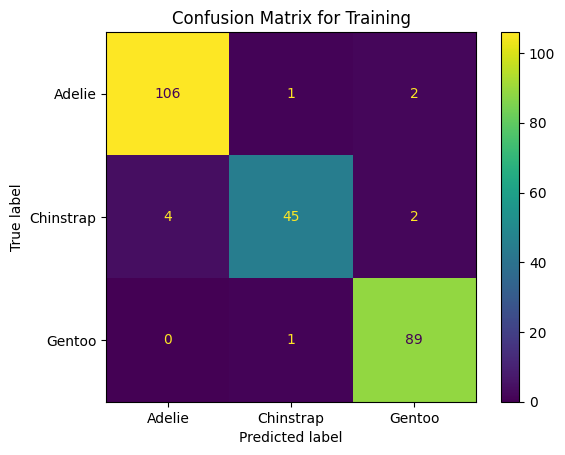


Classification Report:
               precision    recall  f1-score   support

      Adelie       0.96      0.97      0.97       109
   Chinstrap       0.96      0.88      0.92        51
      Gentoo       0.96      0.99      0.97        90

    accuracy                           0.96       250
   macro avg       0.96      0.95      0.95       250
weighted avg       0.96      0.96      0.96       250

accuracy = 0.96
Testing


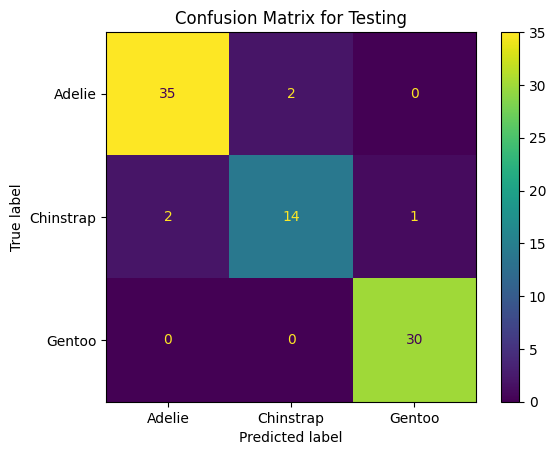


Classification Report:
               precision    recall  f1-score   support

      Adelie       0.95      0.95      0.95        37
   Chinstrap       0.88      0.82      0.85        17
      Gentoo       0.97      1.00      0.98        30

    accuracy                           0.94        84
   macro avg       0.93      0.92      0.93        84
weighted avg       0.94      0.94      0.94        84

accuracy = 0.9404761904761905


In [13]:
# Predictions
y_pred_train = svm_ovo.predict(X_train)
y_pred_test = svm_ovo.predict(X_test)

print("Training")
cfm_train = confusion_matrix(y_train, y_pred_train)
cm_train_display = ConfusionMatrixDisplay(confusion_matrix = cfm_train, display_labels = ["Adelie", "Chinstrap", "Gentoo"])
cm_train_display.plot()
plt.title('Confusion Matrix for Training')
plt.show()
print("\nClassification Report:\n", classification_report(y_train, y_pred_train))
print(f"accuracy = {svm_ovo.score(X_train, y_train)}")

print("Testing")
cfm_test = confusion_matrix(y_test, y_pred_test)
cm_test_display = ConfusionMatrixDisplay(confusion_matrix = cfm_test, display_labels = ["Adelie", "Chinstrap", "Gentoo"])
cm_test_display.plot()
plt.title('Confusion Matrix for Testing')
plt.show()
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))
print(f"accuracy = {svm_ovo.score(X_test, y_test)}")

## **Report the accuracy, macro-averaged F1-score, and confusion matrix of the trained model separately for the training data and testing data.**

## **Answers:**

**For the Training Data:**
*   Accuracy = 96%
*   Macro-averaged F1-score = 95%

**For the Testing Data:**
*   Accuracy = 94.047619%
*   Macro-averaged F1-score = 93%

Confusion Matrix of the Trained Model for both Training and Testing data are shown in the previous cell. From our confusion matrix, we can observe that:

**For the Training Data:**
* Adelie: 106 correct classifications, 3 wrong
* Chinstrap: 45 correct classifications, 6 wrong
* Gentoo: 89 correct classifications, 1 wrong

**For the Testing Data:**
* Adelie: 35 correct classifications, 2 wrong
* Chinstrap: 14 correct classifications, 3 wrong
* Gentoo: 30 correct classifications, 0 wrong

These metrics reflect on the respective Precision, Recall, and F1 Scores for both training and testing data, where:
* Precision = (TP) / (TP + FP)
* Recall = (TP) / (TP + FN)
* Where F1 Score is the harmonic mean between Precision and Recall

**c. [20 pts] For your answer in letter (a), visualize the decision boundary in the space of culmen length vs. flipper length. Add a scatter plot of the training and test data set (use different markers for the two sets).**

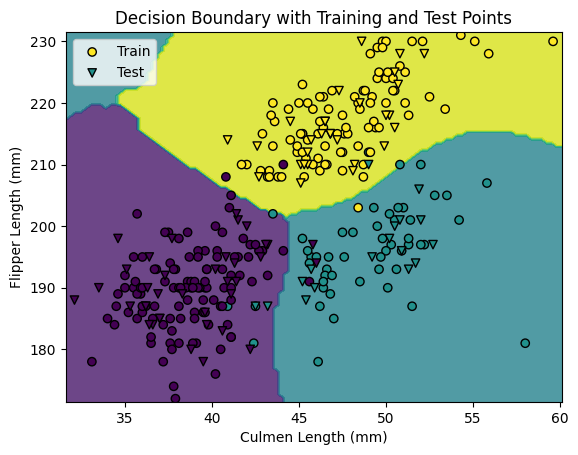

In [14]:
from sklearn.inspection import DecisionBoundaryDisplay

# Map species to integers for coloring
species_map = {"Adelie": 0, "Chinstrap": 1, "Gentoo": 2}
y_train_num = y_train.map(species_map)
y_test_num = y_test.map(species_map)

# Decision boundary
DecisionBoundaryDisplay.from_estimator(svm_ovo, X, alpha=0.8, eps=0.5)
# Training
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train_num, edgecolors="k", marker="o", label="Train")
# Testing
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test_num, edgecolors="k", marker="v", label="Test")

plt.xlabel('Culmen Length (mm)')
plt.ylabel('Flipper Length (mm)')
plt.title('Decision Boundary with Training and Test Points')
plt.legend()
plt.show()

Here shown is a scatter plot of the training and test data set, where the 'o' marker is used for Train, and the 'v' marker is used for the Test data. We are able to successfully visualize the decision boundary in the space of culmen length vs. flipper length.